# 06 — Phục vụ mô hình: độ trễ, thông lượng và hàng đợi

Cổng 4 của dự án đặt mô hình sau một máy chủ gRPC và đo nó dưới 1, 2 và 4 yêu cầu đồng thời.
Kết quả: tăng số yêu cầu đồng thời **không** tăng thông lượng, chỉ làm độ trễ phình ra; còn
giảm độ phân giải thì **gấp đôi** thông lượng. Notebook này giải thích những kết quả đó bằng
**lý thuyết hàng đợi** — công cụ chuẩn để thiết kế năng lực của một dịch vụ — và kiểm chứng
bằng dữ liệu đo và mô phỏng.

Nền tảng cần có: notebook 00 (phân vị, trung bình), notebook 02 (p95), notebook 04 (KV cache,
decode bị giới hạn bởi bộ nhớ). Notebook này chỉ dùng CPU.

| Mục | Nội dung |
|---|---|
| 1 | gRPC và protobuf: một yêu cầu đi qua mạng trông thế nào |
| 2 | Độ trễ và thông lượng |
| 3 | Định luật Little |
| 4 | Hàng đợi khi yêu cầu đến ngẫu nhiên |
| 5 | Lập kế hoạch năng lực theo mục tiêu p95 |
| 6 | Batching và bộ nhớ: con đường để vượt 1 yêu cầu mỗi lượt |

In [1]:
import io, json, math, sys
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "..")                      # main-branch code lives one level up
RESULTS = Path("../results")
rng = np.random.default_rng(0)
plt.rcParams.update({"figure.figsize": (7, 3.2), "figure.dpi": 110})

def load(name):
    return json.loads((RESULTS / name).read_text())

## 1. gRPC và protobuf

**RPC** (remote procedure call) là cách gọi một hàm chạy trên máy khác như thể gọi hàm cục
bộ. **gRPC** là một khung RPC phổ biến; nó mô tả giao diện bằng **protobuf** — một ngôn ngữ
định nghĩa cấu trúc tin nhắn, từ đó sinh ra code cho cả máy chủ lẫn máy khách, và một định dạng
**mã hoá nhị phân** gọn cho các tin nhắn đó. Giao diện của dự án nằm trong `serve/vlm.proto`:

In [2]:
print(Path("../serve/vlm.proto").read_text())

syntax = "proto3";
package vlmspeedrun;

// Inference service for a vision-language model.
// gRPC rather than REST because the payload is binary (an image) and latency matters.
service VlmService {
  rpc Infer (InferRequest) returns (InferReply);
  rpc Health (HealthRequest) returns (HealthReply);
}

message InferRequest {
  bytes image = 1;            // image encoded as PNG or JPEG
  string question = 2;
  int32 max_new_tokens = 3;   // 0 = use the server default
  int32 max_edge = 4;         // 0 = server default; otherwise 768, 1152 or 1536 (768 = fast mode)
}

message InferReply {
  string answer = 1;
  int32 image_tokens = 2;     // image tokens actually used
  float server_ms = 3;        // time measured at the server, excluding network
  float queue_ms = 4;         // time spent waiting in the queue
}

message HealthRequest {}
message HealthReply {
  bool ready = 1;
  string model = 2;
  string device = 3;
  float vram_mb = 4;
}



Dự án chọn gRPC thay vì REST + JSON vì dữ liệu chính là **ảnh nhị phân**. JSON chỉ chứa được văn
bản, nên ảnh phải mã hoá base64 — mỗi 3 byte thành 4 ký tự, tăng khoảng 33%. Protobuf chứa byte
thô trực tiếp. So kích thước một yêu cầu thật:

In [3]:
from serve.gen_proto import ensure_stubs
ensure_stubs()                                  # generate vlm_pb2*.py if missing (they are not in git)
from serve import vlm_pb2
from bench.harness import load_samples
import base64

s = load_samples(1, seed=0)[0]
buf = io.BytesIO(); s["image"].convert("RGB").save(buf, format="PNG"); png = buf.getvalue()

req = vlm_pb2.InferRequest(image=png, question=s["query"], max_edge=768)
wire = req.SerializeToString()
as_json = json.dumps({"image": base64.b64encode(png).decode(), "question": s["query"], "max_edge": 768})
print(f"PNG image         : {len(png):>8,} bytes")
print(f"protobuf request  : {len(wire):>8,} bytes  (+{len(wire) - len(png)} bytes of framing)")
print(f"JSON with base64  : {len(as_json):>8,} bytes  (+{100 * (len(as_json) / len(png) - 1):.0f}%)")

back = vlm_pb2.InferRequest.FromString(wire)
print("round trip intact:", back.image == png and back.question == s["query"])

PNG image         :   31,721 bytes
protobuf request  :   31,836 bytes  (+115 bytes of framing)
JSON with base64  :   42,448 bytes  (+34%)
round trip intact: True


Protobuf chỉ thêm khoảng một trăm byte vào ảnh. Ở quy mô của dự án (vài chục KB mỗi yêu cầu, một GPU),
khác biệt này nhỏ so với gần một giây suy luận — lý do chính để chọn gRPC là giao diện có kiểu
rõ ràng và code sinh tự động. Nhưng ở dịch vụ lớn, 33% băng thông mạng là chi phí thật.

## 2. Độ trễ và thông lượng

Hai đại lượng mô tả một dịch vụ:

- **Độ trễ** (latency) $W$: thời gian từ lúc gửi yêu cầu tới lúc nhận trả lời, **nhìn từ phía
  người dùng**. Gồm thời gian **chờ trong hàng đợi** và thời gian **được phục vụ** $S$.
- **Thông lượng** (throughput) $\lambda$: số yêu cầu hoàn thành mỗi giây, **nhìn từ phía hệ thống**.

Máy chủ của dự án phục vụ **một yêu cầu mỗi lúc** (một khoá bảo vệ GPU, vì chỉ đủ bộ nhớ cho một
mô hình và các yêu cầu chạy song song sẽ tranh nhau GPU). Vậy thông lượng tối đa là

$$\lambda_{\max} = \frac{1}{\mathbb{E}[S]}$$

**Ký hiệu mới**
- $W$: độ trễ đầu-cuối · $S$: thời gian phục vụ một yêu cầu · $\lambda$: thông lượng (yêu cầu/giây)

Dữ liệu cổng 4. Client gửi 40 yêu cầu với số luồng song song cố định; máy chủ trả kèm thời gian
tính của riêng nó (`server_ms`), nên phần còn lại là thời gian chờ:

In [4]:
serving = {edge: load(f"gate4_serving_{edge}.json") for edge in (1536, 768)}
print(f"{'edge':>5} {'conc.':>5} | {'server median':>13} {'end-to-end median':>18} {'waiting':>8} | {'throughput':>10}")
for edge, res in serving.items():
    for c, v in res.items():
        srv, e2e = v["server_ms"]["median"], v["end_to_end_ms"]["median"]
        print(f"{edge:>5} {c:>5} | {srv:10.0f} ms {e2e:15.0f} ms {e2e - srv:6.0f} ms | {v['throughput_rps']:6.2f} req/s")

 edge conc. | server median  end-to-end median  waiting | throughput
 1536     1 |        988 ms             993 ms      5 ms |   0.95 req/s
 1536     2 |       1012 ms            2023 ms   1011 ms |   0.94 req/s
 1536     4 |        931 ms            3912 ms   2981 ms |   1.01 req/s
  768     1 |        538 ms             543 ms      5 ms |   1.83 req/s
  768     2 |        511 ms            1013 ms    502 ms |   1.92 req/s
  768     4 |        497 ms            2076 ms   1578 ms |   1.91 req/s


Ba quan sát, cả ba đều suy ra được từ công thức trên:

1. **Thời gian phục vụ không đổi** theo số yêu cầu đồng thời — GPU vẫn làm từng yêu cầu một
   như cũ.
2. **Thông lượng không đổi** và bằng $1/\mathbb{E}[S]$: khoảng 1 yêu cầu/giây ở cạnh 1536
   ($S \approx 0{,}95$ s), khoảng 2 ở cạnh 768 ($S \approx 0{,}5$ s).
3. **Toàn bộ phần độ trễ tăng thêm là thời gian chờ.** Với 4 yêu cầu cùng lúc, mỗi yêu cầu
   phải chờ khoảng 3 yêu cầu khác phục vụ xong.

Đòn bẩy duy nhất nâng thông lượng ở đây là **giảm $S$** — chính là việc giảm độ phân giải làm.

## 3. Định luật Little

Định luật Little liên hệ ba đại lượng trung bình của **bất kỳ** hệ thống ổn định nào có yêu cầu
đi vào và đi ra:

$$L = \lambda\, W$$

trong đó $L$ là số yêu cầu trung bình **đang có mặt** trong hệ thống (đang chờ hoặc đang được
phục vụ).

**Vì sao đúng — lập luận diện tích.** Vẽ số yêu cầu có mặt theo thời gian trong một khoảng dài
$T$. Diện tích dưới đường đó có thể tính hai cách: bằng $L \times T$ (độ cao trung bình nhân độ
dài), hoặc bằng tổng thời gian có mặt của từng yêu cầu — tức (số yêu cầu, $\lambda T$) nhân (thời
gian trung bình mỗi yêu cầu, $W$). Cho hai cách bằng nhau: $L\,T = \lambda T\, W$. Định luật không
giả định gì về phân phối thời gian đến hay thời gian phục vụ — đó là lý do nó dùng được ở mọi nơi.

**Ký hiệu mới**
- $L$: số yêu cầu trung bình có mặt trong hệ thống · $T$: độ dài khoảng quan sát

Kiểm chứng trên cổng 4: client giữ đúng $c$ yêu cầu đang bay, nên $L \approx c$ và định luật dự đoán
$W \approx c / \lambda$.

In [5]:
print(f"{'edge':>5} {'c':>2} | {'predicted W = c / lambda':>24} {'measured mean W':>16}")
for edge, res in serving.items():
    for c, v in res.items():
        pred = int(c) / v["throughput_rps"] * 1e3
        print(f"{edge:>5} {c:>2} | {pred:21.0f} ms {v['end_to_end_ms']['mean']:13.0f} ms")

 edge  c | predicted W = c / lambda  measured mean W
 1536  1 |                  1050 ms          1050 ms
 1536  2 |                  2132 ms          2110 ms
 1536  4 |                  3972 ms          3832 ms
  768  1 |                   546 ms           546 ms
  768  2 |                  1041 ms          1029 ms
  768  4 |                  2093 ms          2026 ms


Ở cả ba mức đồng thời, dự đoán khớp số đo trong vòng vài phần trăm. Ở $c = 4$, số đo hơi thấp hơn
dự đoán: ở **cuối** lần đo, khi client hết yêu cầu để gửi, hệ thống xả dần từ 4 xuống 0 yêu cầu, nên
$L$ trung bình thực tế hơi thấp hơn 4. Định luật Little đúng cho **trung bình dài hạn**; hiệu ứng khởi
động và kết thúc càng nhỏ khi lần đo càng dài. (Một lần đo cũ chỉ gửi 12 yêu cầu mỗi mức, và chênh
lệch ở $c = 4$ khi đó lớn hơn nhiều — một lý do nữa để chạy phép đo tải đủ lâu.)

## 4. Hàng đợi khi yêu cầu đến ngẫu nhiên

Client của cổng 4 là **vòng kín** (closed loop): chỉ gửi yêu cầu mới khi một yêu cầu cũ xong, nên
hàng đợi không bao giờ dài quá $c$. Người dùng thật thì không chờ nhau: họ gửi yêu cầu vào những
thời điểm **ngẫu nhiên, độc lập**. Mô hình chuẩn cho điều đó là **quá trình Poisson**: khoảng cách
giữa hai yêu cầu liên tiếp tuân theo phân phối mũ với trung bình $1/\lambda$.

Đại lượng quyết định là **mức sử dụng** (utilization):

$$\rho = \lambda\,\mathbb{E}[S] \quad(\text{tỉ lệ thời gian máy chủ bận})$$

Với một máy chủ, yêu cầu đến theo Poisson và thời gian phục vụ có phân phối bất kỳ (hàng đợi
M/G/1), thời gian chờ trung bình có công thức đóng — **công thức Pollaczek–Khinchine**:

$$\mathbb{E}[W_q] = \frac{\lambda\,\mathbb{E}[S^2]}{2\,(1-\rho)}$$

Mẫu số $1-\rho$ là toàn bộ câu chuyện: khi $\rho \to 1$, thời gian chờ **tăng vọt không giới
hạn**. Một máy chủ bận 90% có thời gian chờ gấp 9 lần máy chủ bận 50%
($\tfrac{0{,}9}{0{,}1}$ so với $\tfrac{0{,}5}{0{,}5}$, với cùng phân phối thời gian phục vụ).

**Ký hiệu mới**
- $\rho$: mức sử dụng máy chủ · $W_q$: thời gian chờ trong hàng (không tính thời gian phục vụ)
- M/G/1: đến theo Poisson (M), phục vụ phân phối bất kỳ (G), 1 máy chủ
- $\mathbb{E}[S^2]$: mô-men bậc hai của thời gian phục vụ — thời gian phục vụ càng dao động, chờ càng lâu

Mô phỏng thay vì tin công thức. Thời gian phục vụ lấy từ **dữ liệu thật**: 3.840 lần chạy mỗi cấu
hình (1.920 câu × 2 lượt) trong `gate2_confirm.json`. Thời gian chờ của yêu cầu thứ $k+1$ tính bằng **đệ quy Lindley**:
nó phải chờ phần việc còn lại của yêu cầu trước, trừ đi khoảng cách giữa hai lần đến, không âm:

$$W_{q,k+1} = \max\big(0,\; W_{q,k} + S_k - A_{k+1}\big)$$

**Ký hiệu mới**
- $A_{k+1}$: khoảng thời gian giữa lần đến thứ $k$ và thứ $k+1$

In [6]:
confirm = load("gate2_confirm.json")
service = defaultdict(list)
for r in confirm["records"]:
    service["1536" if r["config"] == "baseline" else "768"].append(r["generate_ms"] / 1e3)
service = {k: np.array(v) for k, v in service.items()}
for k, v in service.items():
    print(f"edge {k}: E[S] = {v.mean():.3f} s, capacity 1/E[S] = {1 / v.mean():.2f} req/s")

def simulate(S_pool, lam, n=200_000):
    """M/G/1 queue: Poisson arrivals at rate lam, service times resampled from real data."""
    S = rng.choice(S_pool, size=n)
    A = rng.exponential(1 / lam, size=n)
    wq = np.empty(n); wq[0] = 0.0
    for k in range(n - 1):
        wq[k + 1] = max(0.0, wq[k] + S[k] - A[k + 1])
    return wq[n // 10:], (wq + S)[n // 10:]          # drop the warm-up tenth

S = service["1536"]
for rho in [0.5, 0.8, 0.9]:
    lam = rho / S.mean()
    wq, _ = simulate(S, lam, n=100_000)
    pk = lam * (S ** 2).mean() / (2 * (1 - rho))
    print(f"edge 1536, rho = {rho}: simulated E[Wq] = {wq.mean():.2f} s | Pollaczek-Khinchine {pk:.2f} s")

edge 768: E[S] = 0.495 s, capacity 1/E[S] = 2.02 req/s
edge 1536: E[S] = 0.954 s, capacity 1/E[S] = 1.05 req/s
edge 1536, rho = 0.5: simulated E[Wq] = 0.49 s | Pollaczek-Khinchine 0.49 s
edge 1536, rho = 0.8: simulated E[Wq] = 1.89 s | Pollaczek-Khinchine 1.94 s
edge 1536, rho = 0.9: simulated E[Wq] = 4.41 s | Pollaczek-Khinchine 4.37 s


Mô phỏng khớp công thức, và cho thấy tốc độ tăng của thời gian chờ: từ 50% lên 90% mức sử dụng,
thời gian chờ tăng khoảng 9 lần.

Giờ vẽ **p50 và p95 của độ trễ đầu-cuối** theo tốc độ yêu cầu đến, cho cả hai cấu hình:

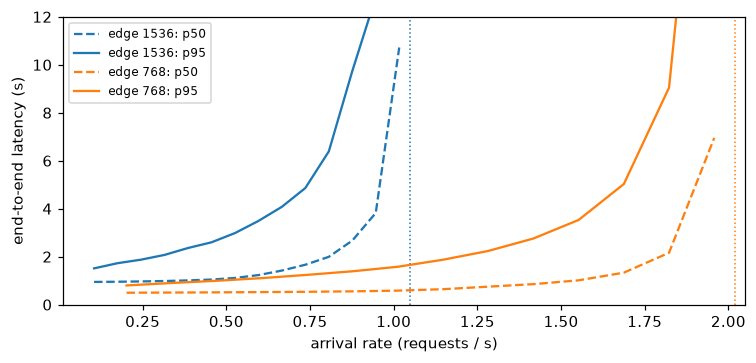

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.4))
curves = {}
for k, color in [("1536", "C0"), ("768", "C1")]:
    S = service[k]; cap = 1 / S.mean()
    lams = np.linspace(0.1, 0.97, 14) * cap
    p50, p95 = [], []
    for lam in lams:
        _, w = simulate(S, lam, n=60_000)
        p50.append(np.percentile(w, 50)); p95.append(np.percentile(w, 95))
    curves[k] = (lams, np.array(p95))
    ax.plot(lams, p50, "--", c=color, label=f"edge {k}: p50")
    ax.plot(lams, p95, "-", c=color, label=f"edge {k}: p95")
    ax.axvline(cap, c=color, ls=":", lw=1)
ax.set_ylim(0, 12); ax.set_xlabel("arrival rate (requests / s)"); ax.set_ylabel("end-to-end latency (s)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

Mỗi đường tăng chậm khi mức sử dụng còn thấp, rồi dựng đứng khi tiến tới đường chấm (năng lực
tối đa). p95 dựng đứng sớm hơn p50 — **đuôi của phân phối độ trễ là thứ hỏng trước tiên**
khi dịch vụ quá tải.

## 5. Lập kế hoạch năng lực theo mục tiêu p95

Trong vận hành, người ta đặt một **mục tiêu mức dịch vụ** (service level objective, SLO), ví dụ
"p95 độ trễ dưới 3 giây", rồi hỏi: **một GPU chịu được bao nhiêu yêu cầu mỗi giây mà vẫn đạt mục
tiêu?** Đọc từ các đường cong trên:

**Ký hiệu mới**
- SLO: mục tiêu định lượng cho một chỉ số dịch vụ, thường là một phân vị độ trễ

In [8]:
for slo in [2.0, 3.0, 5.0]:
    row = []
    for k in ("1536", "768"):
        lams, p95 = curves[k]
        ok = lams[p95 <= slo]
        row.append(f"edge {k}: {ok.max():.2f} req/s" if ok.size else f"edge {k}: not reachable")
    print(f"SLO p95 <= {slo:.0f} s ->  " + " | ".join(row))

SLO p95 <= 2 s ->  edge 1536: 0.25 req/s | edge 768: 1.15 req/s
SLO p95 <= 3 s ->  edge 1536: 0.53 req/s | edge 768: 1.42 req/s
SLO p95 <= 5 s ->  edge 1536: 0.74 req/s | edge 768: 1.55 req/s


Cùng một mục tiêu p95, cấu hình cạnh 768 chịu được **hơn gấp đôi** lưu lượng — và mục tiêu càng
chặt thì tỉ lệ càng lớn (gần 5 lần với p95 ≤ 2 s). Lý do: giảm $S$ vừa nâng năng lực, vừa hạ $\rho$
ở cùng lưu lượng; còn với cạnh 1536, riêng thời gian phục vụ đã chiếm gần hết ngân sách 2 giây,
gần như không còn chỗ cho thời gian chờ. Đây là con số mà một kỹ sư vận hành cần:
không phải "nhanh hơn 1,92×", mà là "với SLO này, một GPU phục vụ được bao nhiêu người dùng".
(Kết quả chính xác phụ thuộc lưới tốc độ mô phỏng; bậc độ lớn và tỉ lệ giữa hai cấu hình mới là
thông tin đáng tin.)

## 6. Batching và bộ nhớ

Máy chủ hiện tại chỉ phục vụ một yêu cầu mỗi lúc, nên $\lambda_{\max} = 1/\mathbb{E}[S]$ là trần
cứng. Cách vượt trần là **batching**: xử lý nhiều yêu cầu trong **cùng một** lượt qua mô hình.

Notebook 04 cho biết khi nào batching có lợi:
- **Decode bị giới hạn bởi băng thông**: đọc trọng số một lần phục vụ được nhiều yêu cầu, nên
  gộp 8 yêu cầu gần như không làm mỗi bước decode chậm đi → thông lượng decode tăng gần 8 lần.
- **Mã hoá thị giác và prefill đã compute-bound**: gộp lô không giảm tổng FLOP, nên lợi ích nhỏ.

Với bài toán hỏi đáp trên ảnh của dự án, hơn 80% thời gian là phần compute-bound, nên batching
chỉ tăng thông lượng ở mức khiêm tốn — khác hẳn với chatbot sinh câu trả lời dài, nơi decode
chiếm phần lớn và batching (các hệ như vLLM) tăng thông lượng hàng chục lần.

Batching còn đụng một giới hạn khác: **bộ nhớ cho KV cache**. Mỗi yêu cầu đang xử lý giữ một KV
cache riêng (notebook 04: khoảng 235 MiB cho một ảnh ở cạnh 1536):

In [9]:
gpu_mib = 6 * 1024
kv_per_req = 235
for name, weights in [("bf16", 4284), ("nf4", 1393)]:
    free = gpu_mib - weights - 500                  # ~500 MiB for activations and kernel workspace
    print(f"{name}: weights {weights} MiB -> about {max(0, free) // kv_per_req} concurrent requests' KV caches fit")

bf16: weights 4284 MiB -> about 5 concurrent requests' KV caches fit
nf4: weights 1393 MiB -> about 18 concurrent requests' KV caches fit


Ở bf16, bộ nhớ còn lại chỉ đủ cho khoảng 5 KV cache; ở nf4, gần gấp bốn. Đây là chỗ lượng tử hoá
**thật sự** có giá trị cho dịch vụ: notebook 05 cho thấy nf4 không làm từng yêu cầu nhanh hơn,
nhưng bộ nhớ nó giải phóng là điều kiện để batching nâng thông lượng. (Con số trên là ước lượng
thô: nó bỏ qua activation của cả lô, vốn tăng theo kích thước lô.)

## Tóm tắt

| Khái niệm | Công thức | Con số trong dự án |
|---|---|---|
| Năng lực một máy chủ | $\lambda_{\max} = 1/\mathbb{E}[S]$ | ~1 req/s (cạnh 1536), ~2 req/s (cạnh 768) |
| Định luật Little | $L = \lambda W$ | $c = 4$: $W \approx 4/\lambda$ |
| Mức sử dụng | $\rho = \lambda\,\mathbb{E}[S]$ | chờ tăng vọt khi $\rho \to 1$ |
| Pollaczek–Khinchine | $\mathbb{E}[W_q] = \dfrac{\lambda\,\mathbb{E}[S^2]}{2(1-\rho)}$ | khớp mô phỏng trên thời gian phục vụ thật |
| Lập kế hoạch năng lực | đọc tốc độ tối đa thoả SLO p95 | cạnh 768 chịu hơn gấp đôi lưu lượng |
| Batching | có lợi ở phần memory-bound | hạn chế ở bài toán này; cần bộ nhớ cho KV cache |